In [1]:
import numpy as np
np.bool = np.bool_ 
import pandas as pd
import os
from tqdm import tqdm

import mxnet as mx
from mxnet import gluon
from mxnet import autograd
from mxnet import image

import sys

from sklearn.metrics import matthews_corrcoef
from scipy.stats import pearsonr

import random

import rasterio
from rasterio.enums import ColorInterp
from rasterio.features import shapes
from scipy import ndimage

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

import higra as hg
import torch
import pickle

import itertools

import imageio.v3 as imageio
from skimage.color import label2rgb
import cv2
from skimage.segmentation import mark_boundaries
from skimage.segmentation import find_boundaries

from shapely.geometry import shape
import shapely
from shapely import Polygon, orient_polygons
from shapely.plotting import plot_polygon
from shapely import ops

import ast

import pyproj

import geopandas as gpd

import seaborn as sns

import matplotlib.font_manager as fm
import matplotlib.colors as colors

In [2]:
file = open('calibration_data/conformal_results_final.pkl', 'rb')
results_table = pickle.load(file)
file.close()

results_table = results_table[results_table['data_split']=='test'].reset_index()

In [3]:
T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(.01, 1, .01)])
T_confidence_set_indices = [10, 28, 4, 15]
T_confidence_set = [0.02, 0.2, 0.005, 0.07]
IOU_threshold = 0.8
IOU_threshold_duplicate_mask = 0.95

def compute_pair_to_iou_dict(polygons):
    indices = np.arange(len(polygons))
    pairs = itertools.combinations(indices, 2)
    pair_to_iou = {}
    for pair in pairs:
        i, j = pair
        if pd.isnull(polygons[i]) or pd.isnull(polygons[j]):
            pair_to_iou[tuple(pair)] = 0
        else:
            pair_to_iou[tuple(pair)] = polygons[i].intersection(polygons[j]).area / polygons[i].union(polygons[j]).area
    return pair_to_iou

def remove_duplicate_masks_finite_sample(indices, pair_to_iou, iou_threshold):
    if len(indices) == 1:
        return indices
    else:
        indices_to_keep = remove_duplicate_masks_finite_sample(indices[:-1], pair_to_iou, iou_threshold)
        for index in indices[:-1]:
            IOU = pair_to_iou[(index, indices[-1])]
            if IOU > iou_threshold:
                return indices_to_keep
        indices_to_keep.append(indices[-1])
        return indices_to_keep

pair_to_iou_dicts = []
for index, row in tqdm(results_table.iterrows(), total=results_table.shape[0]):
    pred_shapes_coord = np.array(row["pred_fields"])[T_confidence_set_indices]
    pair_to_iou_dicts.append(compute_pair_to_iou_dict(pred_shapes_coord))
results_table["Pred Mask Pair to IOUs"] = pair_to_iou_dicts

results_table["Mask Indices"] = results_table["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_finite_sample(list(np.arange(len(T_confidence_set))), x, iou_threshold=IOU_threshold_duplicate_mask))
results_table["Mask Indices nan"] = results_table.apply(lambda x: np.argwhere(pd.isnull(np.array(x["pred_fields_epsg5070_final"])[T_confidence_set_indices])).flatten(), axis=1)
results_table["Final Mask Indices"] = results_table.apply(lambda x: list(set(x["Mask Indices"]) - set(x["Mask Indices nan"])), axis=1)
results_table["Final Mask Number"] = results_table["Final Mask Indices"].apply(lambda x: len(x))
results_table["Final Mask IOUs"] = results_table.apply(lambda x: np.array(x["IOUs_final"])[T_confidence_set_indices][x["Final Mask Indices"]], axis=1)
results_table["Final Mask max IOU"] = results_table["Final Mask IOUs"].map(lambda x: 0 if len(x)==0 else np.max(x))

results_table["conformal_prediction_epsg5070"] = results_table.apply(lambda x: np.array(x["pred_fields_epsg5070_final"])[T_confidence_set_indices][x["Final Mask Indices"]], axis=1)
results_table["conformal_IOU"] = results_table["Final Mask max IOU"]
results_table["conformal_set_size"] = results_table["Final Mask Number"]
results_table["conformal_IOUs"] = results_table["Final Mask IOUs"]

results_table["conformal_prediction_epsg5070_best"] = results_table.apply(lambda x: np.nan if x["conformal_set_size"]==0 else x["conformal_prediction_epsg5070"][np.argmax(x["Final Mask IOUs"])], axis=1)

100%|██████████| 150/150 [00:00<00:00, 215.92it/s]


In [4]:
best_T = np.argwhere(T_values==0.08)[0][0]
results_table["single_best_parameter_prediction_epsg5070"] = results_table.apply(lambda x: np.array(x["pred_fields_epsg5070_final"])[best_T], axis=1)
results_table["single_best_parameter_IOU"] = results_table.apply(lambda x: np.array(x["IOUs_final"])[best_T], axis=1)

In [5]:
results_table = results_table[['image_filename', 'true_field_epsg5070', 'sampled_coords', 'lon_lat',
                               "conformal_prediction_epsg5070", "conformal_prediction_epsg5070_best", "conformal_IOU", "conformal_IOUs", "conformal_set_size",
                               "single_best_parameter_prediction_epsg5070", "single_best_parameter_IOU"]]

baseline_table = pd.read_csv('baseline_comparison_data/test_results.csv')[["image_filename", 
                                                                           "taylor_geospatial_prediction_epsg5070", "taylor_geospatial_IOU", 
                                                                           "usda_prediction_epsg5070", "usda_IOU"]]

results_table = pd.merge(results_table, baseline_table, on='image_filename')

In [6]:
results_table["lon"] = results_table["lon_lat"].apply(lambda x: x[0])
results_table["lat"] = results_table["lon_lat"].apply(lambda x: x[1])

In [7]:
for method in ['taylor_geospatial', 'usda']:
    results_table[f'{method}_prediction_epsg5070'] = results_table[f'{method}_prediction_epsg5070'].apply(lambda x: x if pd.isnull(x) else shapely.from_wkt(x))

results_table["true_field_area"] = results_table['true_field_epsg5070'].apply(lambda x: shapely.area(x))
results_table["conformal_area"] = results_table["conformal_prediction_epsg5070_best"].apply(lambda x: 0 if pd.isnull(x) else shapely.area(x))
for method in ['single_best_parameter', 'taylor_geospatial', 'usda']:
    results_table[f'{method}_area'] = results_table[f'{method}_prediction_epsg5070'].apply(lambda x: 0 if pd.isnull(x) else shapely.area(x))

results_table    

,image_filename,true_field_epsg5070,sampled_coords,lon_lat,conformal_prediction_epsg5070,conformal_prediction_epsg5070_best,conformal_IOU,conformal_IOUs,conformal_set_size,single_best_parameter_prediction_epsg5070,...,taylor_geospatial_IOU,usda_prediction_epsg5070,usda_IOU,lon,lat,true_field_area,conformal_area,single_best_parameter_area,taylor_geospatial_area,usda_area
0,calibration_data/images/0004.tif,POLYGON ((-384979.60558642953 2553182.42175152...,"[931, 632]","[-100.94354666703381, 45.871169396791515]",[POLYGON ((-383934.7491171954 2552815.68116949...,"POLYGON ((-384968.4503368368 2553176, -384784....",0.948083,"[0.15297004039314777, 0.9480825449633247]",2,POLYGON ((-383934.7491171954 2552815.681169492...,...,0.124619,POLYGON ((-384978.14591714257 2553197.43031751...,0.625701,-100.943547,45.871169,2.683420e+06,2.663299e+06,4.161066e+05,2.131633e+07,2.085563e+06
1,calibration_data/images/0007.tif,POLYGON ((618274.3436819421 1319406.9693449077...,"[989, 1018]","[-89.18533864010134, 34.733672695599736]",[POLYGON ((618487.4913983362 1319415.943289111...,"POLYGON ((618272 1319400.484390229, 618514.721...",0.849306,"[0.8297994097294061, 0.7349744782640248, 0.849...",3,"POLYGON ((618272 1319400.484390229, 618515.213...",...,0.000000,POLYGON ((616766.6474736488 1318890.4309811231...,0.103055,-89.185339,34.733673,8.815608e+04,9.289325e+04,1.018696e+05,0.000000e+00,8.484425e+05
2,calibration_data/images/0008.tif,POLYGON ((-622662.6370426221 2692648.040321153...,"[916, 523]","[-104.15432683966857, 46.97755263197039]","[POLYGON ((-622664 2692640, -622601.88854382 2...","POLYGON ((-622664 2692640, -622601.88854382 26...",0.963664,"[0.4774243051815715, 0.963663729995742, 0.2797...",3,"POLYGON ((-622664 2692640, -622601.88854382 26...",...,0.107588,POLYGON ((-622156.6981382059 2692122.313056052...,0.482751,-104.154327,46.977553,6.238681e+05,6.317365e+05,6.265576e+05,5.338483e+06,3.605146e+05
3,calibration_data/images/0009.tif,POLYGON ((-519685.07275860006 2610590.66512130...,"[929, 604]","[-102.73345658449331, 46.31222354108889]",[POLYGON ((-519672.64647053595 2610590.6640617...,POLYGON ((-519672.64647053595 2610590.66406171...,0.963823,"[0.9638230873053941, 0.6513240783386863, 0.701...",3,"POLYGON ((-518832.2460947032 2611336, -518584....",...,0.645600,POLYGON ((-518861.15970181784 2611032.22119198...,0.641821,-102.733457,46.312224,1.253078e+06,1.234736e+06,1.891750e+06,1.826237e+06,1.901485e+06
4,calibration_data/images/0011.tif,POLYGON ((474562.7120643052 2416328.7152097626...,"[533, 1020]","[-89.99782252484759, 44.60244366955982]","[POLYGON ((475147.161733157 2416599.848024658,...","POLYGON ((475147.161733157 2416599.848024658, ...",0.947329,"[0.9473294401827269, 0.35716697168348677]",2,"POLYGON ((475147.161733157 2416599.848024658, ...",...,0.355251,POLYGON ((475713.76744468894 2416779.670987342...,0.341094,-89.997823,44.602444,1.589267e+05,1.607936e+05,4.361847e+05,4.259543e+05,4.265505e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,calibration_data/images/0495.tif,POLYGON ((197358.51923777506 1846655.572070742...,"[701, 637]","[-93.67717395438055, 39.61079663640195]",[POLYGON ((197357.21583911957 1846656.68449781...,POLYGON ((197357.21583911957 1846656.684497810...,0.856100,"[0.8561000030084478, 0.635878124047088, 0.2788...",4,POLYGON ((197258.13810886533 1846648.124782522...,...,0.517694,"POLYGON ((197546.223242701 1846634.1975324957,...",0.727332,-93.677174,39.610797,3.319121e+05,3.233014e+05,4.851661e+05,6.156540e+05,2.777412e+05
146,calibration_data/images/0500.tif,POLYGON ((-211405.1584179754 2189297.417919673...,"[775, 743]","[-98.5918791988612, 42.67485008887307]",[POLYGON ((-211392.74955053045 2189295.7496269...,POLYGON ((-211392.74955053045 2189295.74962699...,0.923309,[0.923308811915706],1,"POLYGON ((-211392.7850165801 2189295.75082923,...",...,0.524559,POLYGON ((-211053.03324304565 2190029.38886671...,0.028326,-98.591879,42.674850,2.583197e+05,2.423672e+05,2.498414e+05

# Visualization of predicted fields

<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("inva

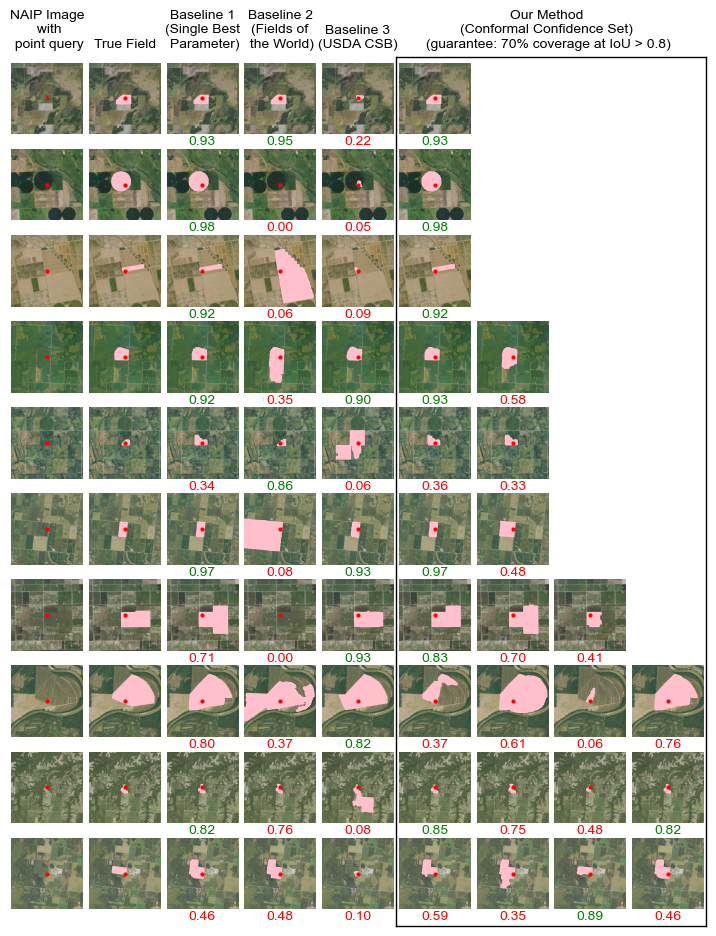

In [10]:
font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=10)          
plt.rc('axes', titlesize=10)     
plt.rc('axes', labelsize=10)    
plt.rc('xtick', labelsize=10)    
plt.rc('ytick', labelsize=10)    
plt.rc('figure', titlesize=10)

method_names = {'true_field': 'True Field',
                'conformal': 'Our Method\n(Conformal Confidence Set)', 
                'single_best_parameter': 'Baseline 1\n(Single Best\n Parameter)',
               'taylor_geospatial': 'Baseline 2\n(Fields of\n the World)',
               'usda': 'Baseline 3\n(USDA CSB)'}

data = results_table.sample(n=10, random_state=0)
data = data.sort_values(by='conformal_set_size').reset_index()

fig, axs = plt.subplots(nrows=10, ncols=9, figsize=(9, 11))
for ax in axs.ravel():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
axs[0,0].set_title("NAIP Image\n with\n point query", y=1.1)
axs[0,5].set_title(f"{method_names['conformal']}\n (guarantee: 70% coverage at IoU > 0.8)", x=2.05, y=1.1)
for i in range(10):
    image_filename = data['image_filename'][i]
    image = imageio.imread(image_filename)
    rgb_img = image[:, :, :3]
    src = rasterio.open(image_filename)
    coord = data['sampled_coords'][i]
    conformal_predictions = data['conformal_prediction_epsg5070'][i]
    
    ncol = len(conformal_predictions) + 5
    for j in range(ncol):
        ax = axs[i, j]
        ax.imshow(rgb_img)
        ax.plot(coord[1], coord[0], "o", color="red", markersize=2)
        ax.set_xlim(coord[1]-256, coord[1]+256)
        ax.set_ylim(coord[0]-256, coord[0]+256)

    for j, method in enumerate(['true_field', 'single_best_parameter', 'taylor_geospatial', 'usda']):
        ax = axs[i, 1+j]
        if method == 'true_field':
            field_epsg5070 = data[f'{method}_epsg5070'][i].exterior.coords
        else:
            IOU = data[f'{method}_IOU'][i]
            if IOU > 0.8:
                ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='green', labelpad=1)
            else:
                ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='red', labelpad=1)
            field_epsg5070 = data[f'{method}_prediction_epsg5070'][i]
            if pd.notnull(field_epsg5070):
                field_epsg5070 = field_epsg5070.exterior.coords
            else:
                continue
        field = []
        for x, y in field_epsg5070:
            col, row = src.index(x, y)
            field.append((row, col))
        field = Polygon(field)
        plot_polygon(field, ax=ax, add_points=False, alpha=1, color='pink')
        if i==0:
            ax.set_title(method_names[method], y=1.1)

    for j, conformal_prediction in enumerate(conformal_predictions):
        ax = axs[i, 5+j]
        IOU = data['conformal_IOUs'][i][j]
        if IOU > 0.8:
            ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='green', labelpad=1)
        else:
            ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='red', labelpad=1)
        field_epsg5070 = conformal_prediction.exterior.coords
        field = []
        for x, y in field_epsg5070:
            col, row = src.index(x, y)
            field.append((row, col))
        field = Polygon(field)
        plot_polygon(field, ax=ax, add_points=False, alpha=1, color='pink')

plt.subplots_adjust(wspace=0.01)
line1 = Line2D([0.555, 0.9], [0.885, 0.885], color="black", linewidth=1, transform=fig.transFigure)
line2 = Line2D([0.555, 0.9], [0.095, 0.095], color="black", linewidth=1, transform=fig.transFigure)
line3 = Line2D([0.555, 0.555], [0.095, 0.885], color="black", linewidth=1, transform=fig.transFigure)
line4 = Line2D([0.9, 0.9], [0.095, 0.885], color="black", linewidth=1, transform=fig.transFigure)
for line in [line1, line2, line3, line4]:
    fig.add_artist(line)
plt.savefig('figures/visualize_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")
<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("inva

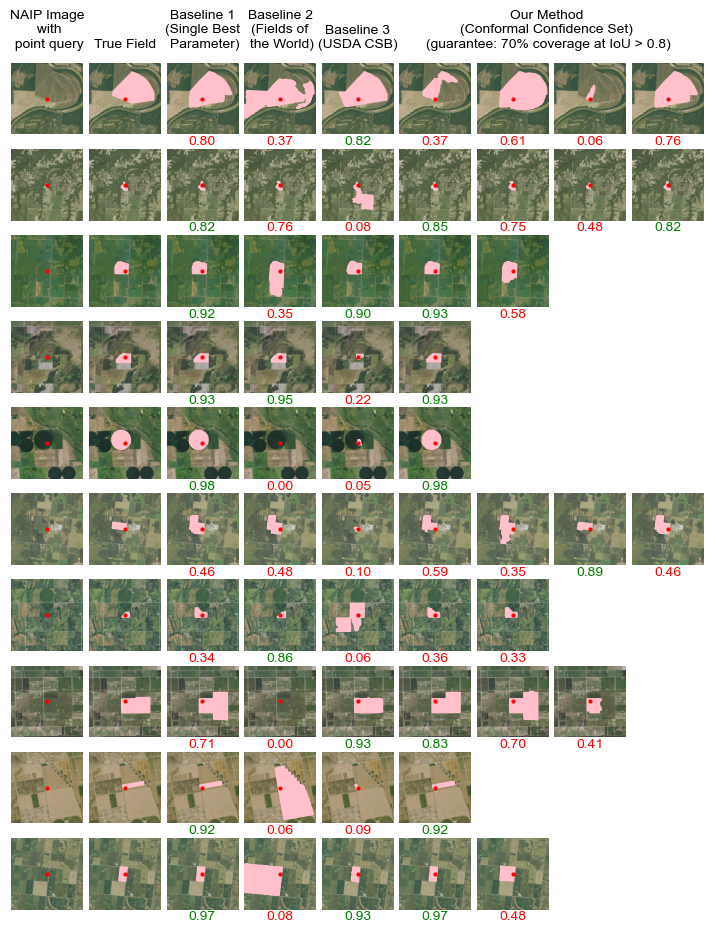

In [16]:
font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=10)          
plt.rc('axes', titlesize=10)     
plt.rc('axes', labelsize=10)    
plt.rc('xtick', labelsize=10)    
plt.rc('ytick', labelsize=10)    
plt.rc('figure', titlesize=10)

method_names = {'true_field': 'True Field',
                'conformal': 'Our Method\n(Conformal Confidence Set)', 
                'single_best_parameter': 'Baseline 1\n(Single Best\n Parameter)',
               'taylor_geospatial': 'Baseline 2\n(Fields of\n the World)',
               'usda': 'Baseline 3\n(USDA CSB)'}

data = results_table.sample(n=10, random_state=0).reset_index()

fig, axs = plt.subplots(nrows=10, ncols=9, figsize=(9, 11))
for ax in axs.ravel():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
axs[0,0].set_title("NAIP Image\n with\n point query", y=1.1)
axs[0,5].set_title(f"{method_names['conformal']}\n (guarantee: 70% coverage at IoU > 0.8)", x=2.05, y=1.1)
for i in range(10):
    image_filename = data['image_filename'][i]
    image = imageio.imread(image_filename)
    rgb_img = image[:, :, :3]
    src = rasterio.open(image_filename)
    coord = data['sampled_coords'][i]
    conformal_predictions = data['conformal_prediction_epsg5070'][i]
    
    ncol = len(conformal_predictions) + 5
    for j in range(ncol):
        ax = axs[i, j]
        ax.imshow(rgb_img)
        ax.plot(coord[1], coord[0], "o", color="red", markersize=2)
        ax.set_xlim(coord[1]-256, coord[1]+256)
        ax.set_ylim(coord[0]-256, coord[0]+256)

    for j, method in enumerate(['true_field', 'single_best_parameter', 'taylor_geospatial', 'usda']):
        ax = axs[i, 1+j]
        if method == 'true_field':
            field_epsg5070 = data[f'{method}_epsg5070'][i].exterior.coords
        else:
            IOU = data[f'{method}_IOU'][i]
            if IOU > 0.8:
                ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='green', labelpad=1)
            else:
                ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='red', labelpad=1)
            field_epsg5070 = data[f'{method}_prediction_epsg5070'][i]
            if pd.notnull(field_epsg5070):
                field_epsg5070 = field_epsg5070.exterior.coords
            else:
                continue
        field = []
        for x, y in field_epsg5070:
            col, row = src.index(x, y)
            field.append((row, col))
        field = Polygon(field)
        plot_polygon(field, ax=ax, add_points=False, alpha=1, color='pink')
        if i==0:
            ax.set_title(method_names[method], y=1.1)

    for j, conformal_prediction in enumerate(conformal_predictions):
        ax = axs[i, 5+j]
        IOU = data['conformal_IOUs'][i][j]
        if IOU > 0.8:
            ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='green', labelpad=1)
        else:
            ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='red', labelpad=1)
        field_epsg5070 = conformal_prediction.exterior.coords
        field = []
        for x, y in field_epsg5070:
            col, row = src.index(x, y)
            field.append((row, col))
        field = Polygon(field)
        plot_polygon(field, ax=ax, add_points=False, alpha=1, color='pink')

plt.subplots_adjust(wspace=0.01)
plt.savefig('figures/visualize_predictions_unordered.png', dpi=300, bbox_inches='tight')
plt.show()

<tifffile.TiffPage 0 @8> parsing GDAL_NODATA tag raised ValueError("invalid literal for int() with base 10: '0.0'")


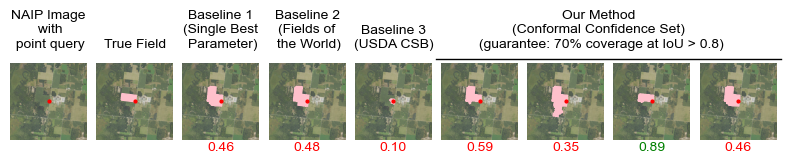

In [50]:
font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=10)          
plt.rc('axes', titlesize=10)     
plt.rc('axes', labelsize=10)    
plt.rc('xtick', labelsize=10)    
plt.rc('ytick', labelsize=10)    
plt.rc('figure', titlesize=10)

method_names = {'true_field': 'True Field',
                'conformal': 'Our Method\n(Conformal Confidence Set)', 
                'single_best_parameter': 'Baseline 1\n(Single Best\n Parameter)',
               'taylor_geospatial': 'Baseline 2\n(Fields of\n the World)',
               'usda': 'Baseline 3\n(USDA CSB)'}

data = results_table.sample(n=10, random_state=0)
data = data.sort_values(by='conformal_set_size').reset_index()
data = data[9:].reset_index()

fig, axs = plt.subplots(nrows=1, ncols=9, figsize=(10, 1))
for ax in axs.ravel():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
axs[0].set_title("NAIP Image\n with\n point query", y=1.1)
axs[5].set_title(f"{method_names['conformal']}\n (guarantee: 70% coverage at IoU > 0.8)", x=2.05, y=1.1)
for i in range(1):
    image_filename = data['image_filename'][i]
    image = imageio.imread(image_filename)
    rgb_img = image[:, :, :3]
    src = rasterio.open(image_filename)
    coord = data['sampled_coords'][i]
    conformal_predictions = data['conformal_prediction_epsg5070'][i]
    
    ncol = len(conformal_predictions) + 5
    for j in range(ncol):
        ax = axs[j]
        ax.imshow(rgb_img)
        ax.plot(coord[1], coord[0], "o", color="red", markersize=2)
        ax.set_xlim(coord[1]-256, coord[1]+256)
        ax.set_ylim(coord[0]-256, coord[0]+256)

    for j, method in enumerate(['true_field', 'single_best_parameter', 'taylor_geospatial', 'usda']):
        ax = axs[1+j]
        if method == 'true_field':
            field_epsg5070 = data[f'{method}_epsg5070'][i].exterior.coords
        else:
            IOU = data[f'{method}_IOU'][i]
            if IOU > 0.8:
                ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='green', labelpad=1)
            else:
                ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='red', labelpad=1)
            field_epsg5070 = data[f'{method}_prediction_epsg5070'][i]
            if pd.notnull(field_epsg5070):
                field_epsg5070 = field_epsg5070.exterior.coords
            else:
                continue
        field = []
        for x, y in field_epsg5070:
            col, row = src.index(x, y)
            field.append((row, col))
        field = Polygon(field)
        plot_polygon(field, ax=ax, add_points=False, alpha=1, color='pink')
        if i==0:
            ax.set_title(method_names[method], y=1.1)

    for j, conformal_prediction in enumerate(conformal_predictions):
        ax = axs[5+j]
        IOU = data['conformal_IOUs'][i][j]
        if IOU > 0.8:
            ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='green', labelpad=1)
        else:
            ax.set_xlabel(f"{np.round(IOU, 2):.2f}", color='red', labelpad=1)
        field_epsg5070 = conformal_prediction.exterior.coords
        field = []
        for x, y in field_epsg5070:
            col, row = src.index(x, y)
            field.append((row, col))
        field = Polygon(field)
        plot_polygon(field, ax=ax, add_points=False, alpha=1, color='pink')

plt.subplots_adjust(wspace=0.01)
line = Line2D([0.555, 0.9], [0.92, 0.92], color="black", linewidth=1, transform=fig.transFigure)
fig.add_artist(line)
plt.savefig('figures/motivating_figure.png', dpi=300, bbox_inches='tight')
plt.show()

# Map of IOUs

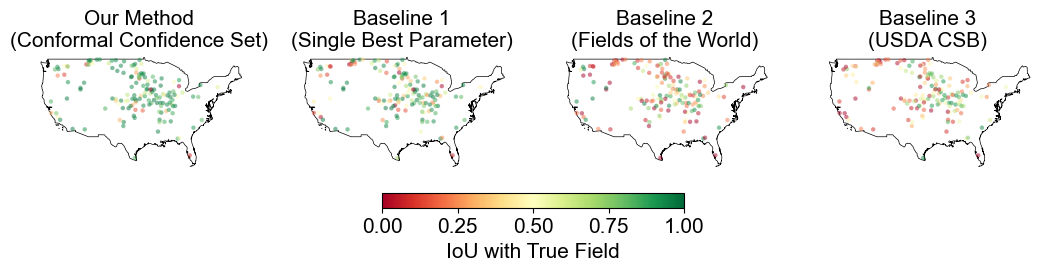

In [52]:
font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

methods = ['conformal', 'single_best_parameter', 'taylor_geospatial', 'usda']
method_names = {'conformal': 'Our Method\n(Conformal Confidence Set)', 
                'single_best_parameter': 'Baseline 1\n(Single Best Parameter)',
               'taylor_geospatial': 'Baseline 2\n(Fields of the World)',
               'usda': 'Baseline 3\n(USDA CSB)'}

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(13, 5))
cmap = plt.get_cmap('RdYlGn')

for i, method in enumerate(methods):
    ax = axs[i]
    
    world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
    usa = world[world.admin == "United States of America"]
    usa.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
    ax.set_xlim(-128, -65)
    ax.set_ylim(23, 50)
    
    gdf = gpd.GeoDataFrame(
        results_table[['lon', 'lat', f'{method}_IOU']], geometry=gpd.points_from_xy(results_table.lon, results_table.lat), crs="EPSG:4326"
    )

    #legend = True if i==3 else False
    sc = gdf.plot(
        ax=ax,
        column=f'{method}_IOU',
        cmap=cmap,
        vmin=0,
        vmax=1,
        s=10,  
        alpha=0.5,
        linewidth=0,
        legend=False
    )
    ax.set_title(method_names[method])
    ax.set_axis_off()
    
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
cbar = fig.colorbar(sm, ax=axs, orientation='horizontal', shrink=0.3, pad=0.05)
cbar.set_label('IoU with True Field')
plt.savefig('figures/IoU_maps.png', dpi=300, bbox_inches='tight')
plt.show()

# Field size

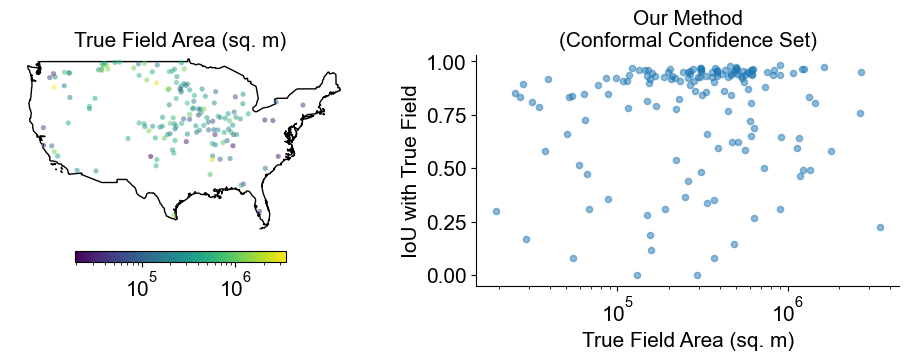

In [105]:
font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

methods = ['conformal', 'single_best_parameter', 'taylor_geospatial', 'usda']
method_names = {'conformal': 'Our Method\n(Conformal Confidence Set)', 
                'single_best_parameter': 'Baseline 1\n(Single Best Parameter)',
               'taylor_geospatial': 'Baseline 2\n(Fields of the World)',
               'usda': 'Baseline 3\n(USDA CSB)'}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 3))

ax = axs[0]
world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
usa = world[world.admin == "United States of America"]
usa.plot(ax=ax, color='white', edgecolor='black')
ax.set_xlim(-128, -65)
ax.set_ylim(23, 50)
gdf = gpd.GeoDataFrame(
    results_table[['lon', 'lat', 'true_field_area']], geometry=gpd.points_from_xy(results_table.lon, results_table.lat), crs="EPSG:4326"
)
sc = gdf.plot(
    ax=ax,
    column='true_field_area', 
    cmap='viridis', 
    norm=colors.LogNorm(),
    s=14,  
    alpha=0.5,
    linewidth=0,
    legend=True,
    legend_kwds={'orientation':'horizontal', 'shrink':0.5, 'pad':0.05}
) 
ax.set_title('True Field Area (sq. m)')
ax.set_axis_off()

ax = axs[1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.scatter(results_table['true_field_area'], results_table['conformal_IOU'], s=20, alpha=0.5)
ax.set_title('Our Method\n(Conformal Confidence Set)')
ax.set_xlabel("True Field Area (sq. m)")
ax.set_ylabel("IoU with True Field")
ax.set_xscale('log')

plt.savefig('figures/true_field_area.png', dpi=300, bbox_inches='tight')
plt.show()

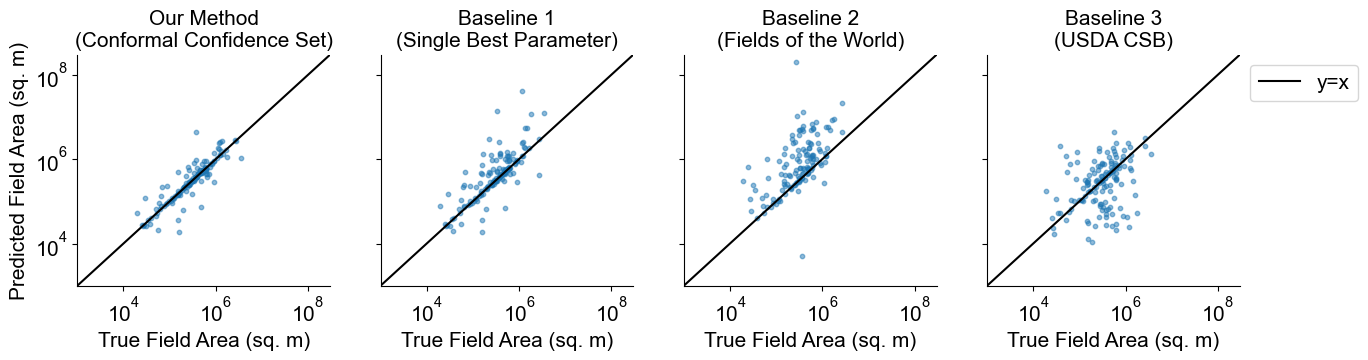

In [104]:
font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

methods = ['conformal', 'single_best_parameter', 'taylor_geospatial', 'usda']
method_names = {'conformal': 'Our Method\n(Conformal Confidence Set)', 
                'single_best_parameter': 'Baseline 1\n(Single Best Parameter)',
               'taylor_geospatial': 'Baseline 2\n(Fields of the World)',
               'usda': 'Baseline 3\n(USDA CSB)'}
fig, axs = plt.subplots(nrows=1, ncols=4, sharey=True, figsize=(15, 3))
for i, method in enumerate(methods):
    ax = axs[i]
    ax.axline((0, 0), (1000000, 1000000), color='black', label='y=x')
    ax.scatter(results_table['true_field_area'], results_table[f'{method}_area'], s=10, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(method_names[method])
    ax.set_xlabel("True Field Area (sq. m)")
    ax.set_xscale('log')
    ax.set_xlim(1000, 300000000)
    if i==0:
        ax.set_ylabel("Predicted Field Area (sq. m)")
    ax.set_yscale('log')
    ax.set_ylim(1000, 300000000)

plt.legend(bbox_to_anchor=(1, 1))
plt.savefig('figures/predicted_field_area_vs_true_field_area.png', dpi=300, bbox_inches='tight')
plt.show()

# Conformal set size

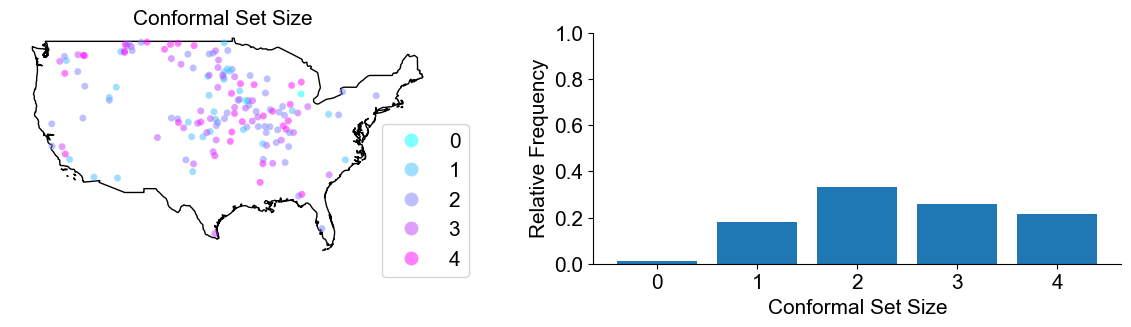

In [8]:
font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 3))

ax = axs[0]
world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
usa = world[world.admin == "United States of America"]
usa.plot(ax=ax, color='white', edgecolor='black')
ax.set_xlim(-128, -65)
ax.set_ylim(23, 50)
gdf = gpd.GeoDataFrame(
    results_table[['lon', 'lat', 'conformal_set_size']], geometry=gpd.points_from_xy(results_table.lon, results_table.lat), crs="EPSG:4326"
)
sc = gdf.plot(
    ax=ax,
    column='conformal_set_size', 
    cmap=plt.get_cmap('cool', 5),  
    categorical=True,
    s=25,  
    alpha=0.5,
    linewidth=0,
    legend=True,
    legend_kwds={
        'frameon': True,
        'bbox_to_anchor':(1.1, 0.65)
    }
) 
ax.set_title('Conformal Set Size')
ax.set_axis_off()

ax = axs[1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.bar(results_table['conformal_set_size'].value_counts().index, results_table['conformal_set_size'].value_counts().values/len(results_table))
ax.set_xticks(np.arange(0, 5))
ax.set_ylim([0, 1])
ax.set_xlabel("Conformal Set Size")
ax.set_ylabel("Relative Frequency")

plt.savefig('figures/conformal_set_size.png', dpi=300, bbox_inches='tight')
plt.show()

In [108]:
print(results_table['conformal_set_size'].value_counts().sort_index() / len(results_table))

conformal_set_size
0    0.013333
1    0.180000
2    0.333333
3    0.260000
4    0.213333
Name: count, dtype: float64


In [109]:
set_sizes = [1, 2, 3, 4]
methods = ['conformal', 'single_best_parameter', 'taylor_geospatial', 'usda']
coverages = {}
mean_ious = {}
median_ious = {}
for method in methods:
    coverage = []
    mean_iou = []
    median_iou = []
    for set_size in set_sizes:
        df = results_table[results_table['conformal_set_size']==set_size]
        ious = df[method+"_IOU"]
        mean_iou.append(np.mean(ious))
        median_iou.append(np.median(ious))
        coverage.append(len(df[ious>IOU_threshold])/len(df))
    coverages[method] = coverage
    mean_ious[method] = mean_iou
    median_ious[method] = median_iou

print("Coverages")
print(coverages)
print("--")
print("Mean IoUs")
print(mean_ious)
print("--")
print("Median IoUs")
print(median_ious)

Coverages
{'conformal': [0.8518518518518519, 0.74, 0.5897435897435898, 0.5625], 'single_best_parameter': [0.8518518518518519, 0.54, 0.4358974358974359, 0.21875], 'taylor_geospatial': [0.2962962962962963, 0.2, 0.1794871794871795, 0.15625], 'usda': [0.2222222222222222, 0.2, 0.1794871794871795, 0.15625]}
--
Mean IoUs
{'conformal': [0.8475108681886611, 0.7932936572597389, 0.7751993166385759, 0.7265177172134375], 'single_best_parameter': [0.8370305878273122, 0.6923460705934058, 0.6488123872476136, 0.4712890979126305], 'taylor_geospatial': [0.48195887085270916, 0.40644508325686, 0.44229165882846505, 0.3352287056087063], 'usda': [0.4353930080577922, 0.4359388878775037, 0.47225129318458414, 0.37598015337191026]}
--
Median IoUs
{'conformal': [0.9345935856151648, 0.9227270001006793, 0.849305553060305, 0.8325346409091856], 'single_best_parameter': [0.9435714082592246, 0.8188603674909354, 0.705056093491514, 0.4212855059787976], 'taylor_geospatial': [0.4924134828344862, 0.3501982177695605, 0.364024

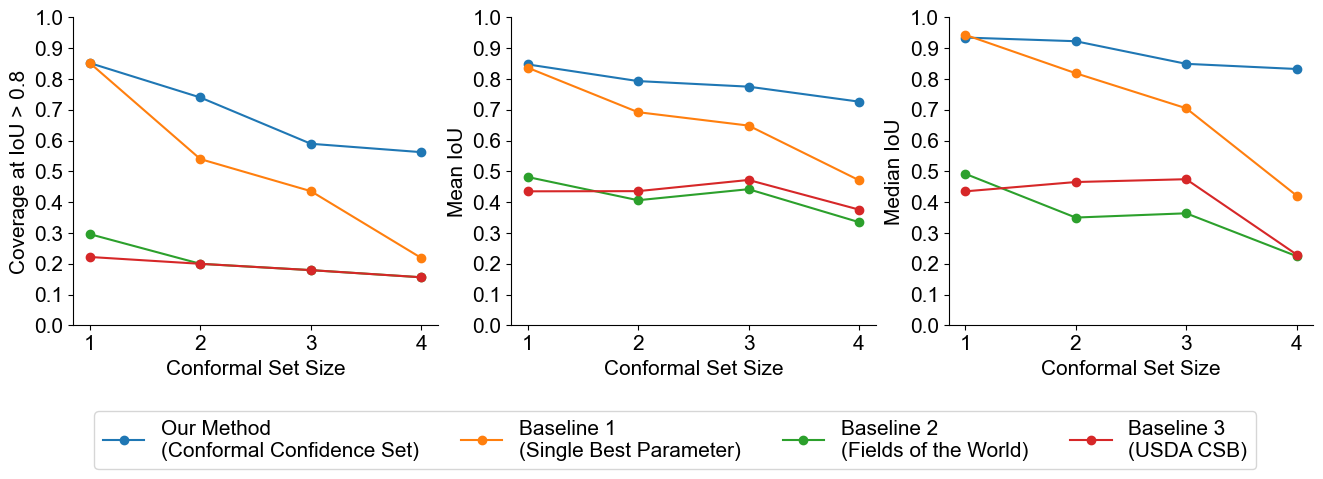

In [110]:
font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

method_names = {'conformal': 'Our Method\n(Conformal Confidence Set)', 
                'single_best_parameter': 'Baseline 1\n(Single Best Parameter)',
               'taylor_geospatial': 'Baseline 2\n(Fields of the World)',
               'usda': 'Baseline 3\n(USDA CSB)'}
aggregate_stats_names = {f"Coverage at IoU > {IOU_threshold}":coverages, "Mean IoU":mean_ious, "Median IoU":median_ious}

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
for i, (ylabel, aggregate_stats) in enumerate(aggregate_stats_names.items()):
    ax = axs[i]
    for method, stats in aggregate_stats.items():
        ax.plot(set_sizes, stats, label=method_names[method], marker='o')
    ax.set_xlabel("Conformal Set Size")
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(1, 5, 1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.legend(loc='lower center', bbox_to_anchor=(-0.75, -0.5), ncol=4)
plt.savefig('figures/performance_vs_conformal_set_size.png', dpi=300, bbox_inches='tight')
plt.show()